# Классификация действий человека по тепловым видеоданным

В данном ноутбуке реализован pipeline для классификации действий человека на основе последовательностей тепловых кадров.
Модель использует предварительную обработку видео, выделение признаков движения, преобразование кадров в событийное представление и нейросетевую архитектуру с LIF-слоем, temporal convolution и attention pooling.

## 1. Цель работы

Цель — построить модель, способную классифицировать действия человека по тепловому видео.

Основные этапы:

* загрузка и обработка метаданных;
* чтение тепловых видео;
* выделение информативных временных окон;
* формирование событийных каналов;
* обучение модели;
* оценка качества на тестовой выборке;
* анализ ошибок классификации.

## 2. Используемые классы

В текущей версии используются следующие классы:
> В данной версии эксперимента исходные действия сгруппированы в 3 обобщённых класса.

| ID | Класс              |
| -: | ------------------ |
|  0 | passive_state      |
|  1 | object_interaction |
|  2 | physical_activity  |

## 3. Структура pipeline

1. Видео загружается как последовательность grayscale-кадров.
2. Для каждого видео выбираются action-aware окна.
3. Каждый фрагмент преобразуется в многоканальное событийное представление.
4. Модель извлекает пространственные и временные признаки.
5. Финальная классификация выполняется по агрегированным признакам видео.

## 4. Оценка качества

Для оценки используются:

* accuracy;
* macro F1-score;
* recall по каждому классу;
* confusion matrix;
* таблица ошибочных предсказаний.

## 5. Итоговый результат

Лучшая модель выбирается по пользовательской метрике `model_selection_score`, учитывающей macro F1 и recall по классам.


In [37]:
!pip install snntorch tqdm

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Загрузка библиотек

In [39]:
import os
import random
import math
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import accuracy_score, f1_score,confusion_matrix, ConfusionMatrixDisplay, classification_report

import snntorch as snn
from snntorch import surrogate
from snntorch import utils
from tqdm.auto import tqdm
from scipy.signal import find_peaks

In [40]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


set_seed(123)

# Загрузка данных

In [41]:
def load_grayscale_video(video_path, resize=(128, 128)):
    cap = cv2.VideoCapture(video_path)

    frames = []

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        if resize is not None:
            gray = cv2.resize(gray, resize, interpolation=cv2.INTER_AREA)

        gray = gray.astype(np.float32) / 255.0

        # [1, H, W]
        gray = gray[None, :, :]

        frames.append(gray)

    cap.release()

    if len(frames) == 0:
        raise ValueError(f"Empty video: {video_path}")

    frames = np.stack(frames, axis=0)  # [T, 1, H, W]

    return frames.astype(np.float32)


In [42]:
DATA_ROOT = Path("/content/drive/MyDrive/dataset_v7")
META_PATH = DATA_ROOT / "metadata.csv"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin_memory = True if torch.cuda.is_available() else False
print("device:", device)

class_to_idx = {
    "passive_state": 0,
    "object_interaction": 1,
    "physical_activity": 2
}
idx_to_class = {v: k for k, v in class_to_idx.items()}
df = pd.read_csv(META_PATH)

device: cuda


## Визуализация классов

In [43]:
class_counts = (
    df.groupby(["split", "full_label"])
    .size()
    .reset_index(name="count")
    .sort_values(["split", "count"], ascending=[True, False])
)

display(class_counts)

,split,full_label,count
3,test,sit chair,15
5,test,sit sofa,15
8,test,touch book,15
9,test,touch bottle,15
12,test,touch phone,15
4,test,sit desk,14
10,test,touch cabinet,10
6,test,sit stool,9
11,test,touch chair,7
1,test,lie sofa,6


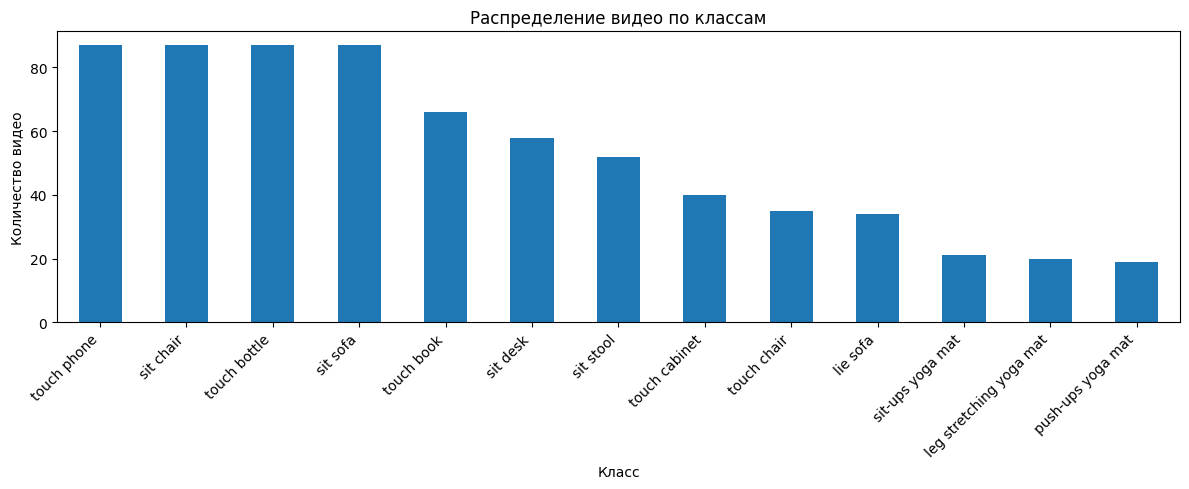

In [44]:
plt.figure(figsize=(12, 5))
df["full_label"].value_counts().plot(kind="bar")
plt.title("Распределение видео по классам")
plt.xlabel("Класс")
plt.ylabel("Количество видео")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Предобработка данных

In [45]:
def temporal_resample_frames(frames, target_len):
    """
    frames: [T, C, H, W]
    Возвращает [target_len, C, H, W]

    Без reverse / ping-pong.
    Только временное растяжение или сжатие.
    """
    T = len(frames)

    if T == 0:
        raise ValueError("Empty video")

    if T == 1:
        return np.repeat(frames, target_len, axis=0).astype(np.float32)

    new_idx = np.linspace(0, T - 1, target_len)

    left = np.floor(new_idx).astype(np.int64)
    right = np.ceil(new_idx).astype(np.int64)

    alpha = new_idx - left
    alpha = alpha.reshape(-1, 1, 1, 1).astype(np.float32)

    resampled = (1.0 - alpha) * frames[left] + alpha * frames[right]

    return resampled.astype(np.float32)


def make_short_video_windows(
    frames_all,
    window_size=32,
    n_windows=8,
    split="train",
):
    """
    Для коротких видео:
    - не делаем ping-pong;
    - не разворачиваем время;
    - растягиваем видео до window_size;
    - на train добавляем лёгкий temporal jitter.
    """
    T = len(frames_all)

    base = temporal_resample_frames(
        frames_all,
        target_len=window_size
    )

    windows = [base]

    if split == "train" and T > 2:
        for _ in range(n_windows - 1):
            scale = np.random.uniform(0.90, 1.10)

            center = (T - 1) / 2.0

            new_idx = np.linspace(0, T - 1, window_size)
            new_idx = center + (new_idx - center) * scale
            new_idx = np.clip(new_idx, 0, T - 1)

            left = np.floor(new_idx).astype(np.int64)
            right = np.ceil(new_idx).astype(np.int64)

            alpha = new_idx - left
            alpha = alpha.reshape(-1, 1, 1, 1).astype(np.float32)

            window = (1.0 - alpha) * frames_all[left] + alpha * frames_all[right]
            windows.append(window.astype(np.float32))

            if len(windows) >= n_windows:
                break

    while len(windows) < n_windows:
        windows.append(base.copy())

    return np.stack(windows[:n_windows], axis=0).astype(np.float32)


In [46]:
def get_foreground_mask(frame, q=75):
    """
    frame: [1, H, W] или [H, W]
    Возвращает foreground mask: [H, W]
    """
    if frame.ndim == 3:
        img = frame[0]
    else:
        img = frame

    threshold = np.percentile(img, q)
    mask = (img >= threshold).astype(np.float32)

    return mask


def smooth_signal(x, kernel_size=9):
    x = np.asarray(x, dtype=np.float32)

    if len(x) < kernel_size:
        return x

    kernel = np.ones(kernel_size, dtype=np.float32) / kernel_size
    return np.convolve(x, kernel, mode="same")


def compute_foreground_motion(frames_all):
    """
    frames_all: [T, 1, H, W]

    Возвращает словарь:
    - energy: сила движения внутри foreground
    - area: площадь активного движения
    - cx, cy: центр активного движения
    """
    frames = np.asarray(frames_all).astype(np.float32)

    T = len(frames)

    if T < 2:
        zeros = np.zeros(T, dtype=np.float32)

        return {
            "energy": zeros,
            "area": zeros,
            "cx": np.full(T, 0.5, dtype=np.float32),
            "cy": np.full(T, 0.5, dtype=np.float32),
        }

    energies = []
    areas = []
    cxs = []
    cys = []

    for t in range(1, T):
        prev = frames[t - 1, 0]
        curr = frames[t, 0]

        fg_prev = get_foreground_mask(frames[t - 1], q=75)
        fg_curr = get_foreground_mask(frames[t], q=75)

        fg = np.maximum(fg_prev, fg_curr)

        diff = np.abs(curr - prev)
        diff_fg = diff * fg

        fg_sum = fg.sum()

        if fg_sum > 0:
            energy = diff_fg.sum() / (fg_sum + 1e-6)
        else:
            energy = diff.mean()

        if fg_sum > 0:
            valid_values = diff_fg[fg > 0]

            if len(valid_values) > 0:
                thr = np.percentile(valid_values, 85)
            else:
                thr = diff_fg.mean()

            active = diff_fg > thr
        else:
            active = diff_fg > diff_fg.mean()

        ys, xs = np.where(active)

        if len(xs) > 0:
            cx = xs.mean() / curr.shape[1]
            cy = ys.mean() / curr.shape[0]
            area = len(xs) / curr.size
        else:
            cx = 0.5
            cy = 0.5
            area = 0.0

        energies.append(float(energy))
        areas.append(float(area))
        cxs.append(float(cx))
        cys.append(float(cy))

    energies = np.array([energies[0]] + energies, dtype=np.float32)
    areas = np.array([areas[0]] + areas, dtype=np.float32)
    cxs = np.array([cxs[0]] + cxs, dtype=np.float32)
    cys = np.array([cys[0]] + cys, dtype=np.float32)

    energies = smooth_signal(energies, kernel_size=7)
    areas = smooth_signal(areas, kernel_size=7)
    cxs = smooth_signal(cxs, kernel_size=7)
    cys = smooth_signal(cys, kernel_size=7)

    return {
        "energy": energies,
        "area": areas,
        "cx": cxs,
        "cy": cys,
    }

In [47]:
def window_score_action(stats, start, window_size):
    end = min(start + window_size, len(stats["energy"]))

    energy = stats["energy"][start:end]
    area = stats["area"][start:end]
    cx = stats["cx"][start:end]
    cy = stats["cy"][start:end]

    if len(energy) == 0:
        return 0.0

    mean_energy = float(np.mean(energy))
    max_energy = float(np.max(energy))
    std_energy = float(np.std(energy))

    mean_area = float(np.mean(area))

    if len(cx) > 1:
        centroid_shift = float(
            np.mean(np.abs(np.diff(cx))) +
            np.mean(np.abs(np.diff(cy)))
        )
    else:
        centroid_shift = 0.0

    local_motion = mean_energy * np.exp(-4.0 * mean_area)

    score = (
        0.35 * mean_energy +
        0.25 * max_energy +
        0.20 * std_energy +
        0.25 * local_motion +
        0.10 * centroid_shift
    )

    return float(score)


def suppress_nearby_starts(starts, scores, min_distance):
    order = np.argsort(scores)[::-1]

    selected = []

    for idx in order:
        s = int(starts[idx])

        if all(abs(s - prev) >= min_distance for prev in selected):
            selected.append(s)

    return selected


In [48]:
def choose_starts_action_aware(
    frames_all,
    window_size,
    n_windows,
    split="train",
    seed=None,
):
    total_frames = len(frames_all)

    if total_frames <= 0:
        return [0] * n_windows

    max_start = max(0, total_frames - window_size)

    if max_start == 0:
        return [0] * n_windows

    rng = np.random.default_rng(seed)

    stats = compute_foreground_motion(frames_all)

    stride = max(1, window_size // 4)

    candidate_starts = list(range(0, max_start + 1, stride))

    if candidate_starts[-1] != max_start:
        candidate_starts.append(max_start)

    candidate_scores = np.array(
        [
            window_score_action(stats, s, window_size)
            for s in candidate_starts
        ],
        dtype=np.float32
    )

    starts = []

    n_uniform = max(3, int(round(n_windows * 0.35)))

    uniform_starts = np.linspace(
        0,
        max_start,
        n_uniform
    ).astype(np.int64).tolist()

    starts.extend(uniform_starts)

    n_action = max(3, int(round(n_windows * 0.45)))

    action_starts = suppress_nearby_starts(
        candidate_starts,
        candidate_scores,
        min_distance=max(1, window_size // 2)
    )

    starts.extend(action_starts[:n_action])

    if len(action_starts) > 0:
        peak = action_starts[0]

        context = [
            peak - window_size // 2,
            peak - window_size // 4,
            peak,
            peak + window_size // 4,
        ]

        for s in context:
            s = int(max(0, min(s, max_start)))
            starts.append(s)

    current_unique_count = len(set(starts))
    n_low_context = max(1, n_windows - current_unique_count)

    low_order = np.argsort(candidate_scores)

    for idx in low_order:
        if len(set(starts)) >= n_windows:
            break

        s = int(candidate_starts[idx])
        starts.append(s)

    unique = []

    for s in starts:
        s = int(max(0, min(s, max_start)))

        if s not in unique:
            unique.append(s)

    starts = unique

    while len(starts) < n_windows:
        if split == "train":
            s = int(rng.integers(0, max_start + 1))
        else:
            pos = len(starts) / max(1, n_windows - 1)
            s = int(round(pos * max_start))

        starts.append(s)

    starts = starts[:n_windows]

    if split == "train":
        jitter = max(1, window_size // 12)

        jittered = []

        for s in starts:
            delta = int(rng.integers(-jitter, jitter + 1))
            sj = int(max(0, min(s + delta, max_start)))
            jittered.append(sj)

        starts = jittered

    return starts


In [49]:
def frames_to_events(frames, threshold=0.04):
    """
    frames: [T, 1, H, W]
    return: [T, 7, H, W]
    """
    thermal = frames.astype(np.float32)

    T, C, H, W = thermal.shape

    if T < 2:
        zeros = np.zeros_like(thermal)

        fg_masks = []

        for t in range(T):
            mask = get_foreground_mask(thermal[t], q=75)
            fg_masks.append(mask[None, :, :])

        fg_masks = np.stack(fg_masks, axis=0).astype(np.float32)

        combined = np.concatenate(
            [
                thermal,
                zeros,
                zeros,
                zeros,
                fg_masks,
                zeros,
                zeros,
            ],
            axis=1
        )

        return combined.astype(np.float32)

    delta = thermal[1:] - thermal[:-1]
    abs_delta = np.abs(delta)

    adaptive_thr = np.percentile(abs_delta, 85)
    adaptive_thr = max(float(adaptive_thr), float(threshold))

    pos_events = np.maximum(delta - adaptive_thr, 0.0)
    neg_events = np.maximum(-delta - adaptive_thr, 0.0)

    pos_events = np.clip(pos_events / 0.2, 0.0, 1.0)
    neg_events = np.clip(neg_events / 0.2, 0.0, 1.0)

    motion_mag = np.clip(abs_delta, 0.0, 0.2) / 0.2

    zero_event = np.zeros(
        (1, 1, H, W),
        dtype=np.float32
    )

    pos_events = np.concatenate([zero_event, pos_events], axis=0)
    neg_events = np.concatenate([zero_event, neg_events], axis=0)
    motion_mag = np.concatenate([zero_event, motion_mag], axis=0)

    fg_masks = []

    for t in range(T):
        mask = get_foreground_mask(thermal[t], q=75)
        fg_masks.append(mask[None, :, :])

    fg_masks = np.stack(fg_masks, axis=0).astype(np.float32)

    fg_motion = motion_mag * fg_masks

    motion_history = np.zeros_like(motion_mag)

    decay = 0.85

    for t in range(1, T):
        motion_history[t] = (
            decay * motion_history[t - 1] +
            motion_mag[t]
        )

    motion_history = np.clip(motion_history, 0.0, 1.0)

    combined = np.concatenate(
        [
            thermal,
            pos_events,
            neg_events,
            motion_mag,
            fg_masks,
            fg_motion,
            motion_history,
        ],
        axis=1
    )

    return combined.astype(np.float32)


def frames_to_events_windows(windows, threshold=0.04):
    """
    windows: [N, T, 1, H, W]
    return: [N, T, 7, H, W]
    """
    events_list = []

    for frames in windows:
        events = frames_to_events(
            frames,
            threshold=threshold
        )

        events_list.append(events)

    return np.stack(events_list, axis=0).astype(np.float32)

In [50]:
def show_event_channels(event_tensor, frame_idx=0):
    channel_names = [
        "thermal",
        "positive_events",
        "negative_events",
        "motion_magnitude",
        "foreground_mask",
        "foreground_motion",
        "motion_history",
    ]

    plt.figure(figsize=(14, 6))

    for i, name in enumerate(channel_names):
        plt.subplot(2, 4, i + 1)
        plt.imshow(event_tensor[frame_idx, i], cmap="gray")
        plt.title(name)
        plt.axis("off")

    plt.suptitle(f"Событийные каналы для кадра {frame_idx}")
    plt.tight_layout()
    plt.show()

In [51]:
def show_video_frames(frames, title="Пример кадров", n=8):
    idxs = np.linspace(0, len(frames) - 1, n).astype(int)

    plt.figure(figsize=(14, 3))

    for i, idx in enumerate(idxs):
        plt.subplot(1, n, i + 1)
        frame = frames[idx, 0]
        plt.imshow(frame, cmap="gray")
        plt.title(f"t={idx}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [52]:
def load_video_windows(
    video_path,
    window_size=32,
    resize=(128, 128),
    threshold=0.04,
    n_windows=12,
    mode="action_aware",
    split="train",
    class_id=None,
):
    frames_all = load_grayscale_video(video_path, resize=resize)
    total_frames = len(frames_all)

    if total_frames < window_size:
        windows = make_short_video_windows(
            frames_all, window_size=window_size, n_windows=n_windows, split=split
        )
        return frames_to_events_windows(windows, threshold=threshold)


    starts = choose_starts_action_aware(
        frames_all, window_size, n_windows, split=split
    )

    if len(starts) < n_windows:
        max_start = total_frames - window_size
        additional = np.linspace(0, max_start, n_windows - len(starts)).astype(int).tolist()
        starts.extend(additional)
    elif len(starts) > n_windows:
        starts = starts[:n_windows]

    max_start = total_frames - window_size
    windows = []

    for s in starts:
        s = int(max(0, min(s, max_start)))
        window = frames_all[s:s + window_size]

        if len(window) < window_size:
            window = temporal_resample_frames(window, target_len=window_size)
        windows.append(window)

    windows = np.stack(windows, axis=0).astype(np.float32)
    return frames_to_events_windows(windows, threshold=threshold)

# Датасет

In [53]:
class ThermalVideoDataset(Dataset):
    def __init__(
        self,
        df,
        data_root,
        split="train",
        window_size=32,
        resize=(128, 128),
        threshold=0.04,
        n_windows=5,
        mode="hybrid",
    ):
        self.df = df[df["split"] == split].reset_index(drop=True).copy()
        self.data_root = Path(data_root)
        self.split = split
        self.window_size = window_size
        self.resize = resize
        self.threshold = threshold
        self.n_windows = n_windows
        self.mode = mode
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        video_path = self.data_root / row["filepath"]
        class_id = int(row["class_id"])

        windows = load_video_windows(
            video_path,
            window_size=self.window_size,
            resize=self.resize,
            n_windows=self.n_windows,
            mode=self.mode,  # передаём режим
            split=self.split,
            class_id=class_id,  # передаём для персонализации
        )

        windows = torch.from_numpy(windows).float()
        label = torch.tensor(class_id, dtype=torch.long)

        return windows, label

In [54]:
train_dataset = ThermalVideoDataset(
    df,
    DATA_ROOT,
    split="train",
    window_size=40,
    resize=(128, 128),
    threshold=0.04,
    n_windows=10,
    mode="action_aware",
)

val_dataset = ThermalVideoDataset(
    df,
    DATA_ROOT,
    split="val",
    window_size=40,
    resize=(128, 128),
    threshold=0.04,
    n_windows=10,
    mode="action_aware",
)

test_dataset = ThermalVideoDataset(
    df,
    DATA_ROOT,
    split="test",
    window_size=40,
    resize=(128, 128),
    threshold=0.04,
    n_windows=10,
    mode="action_aware",
)

## Пример исходного видео

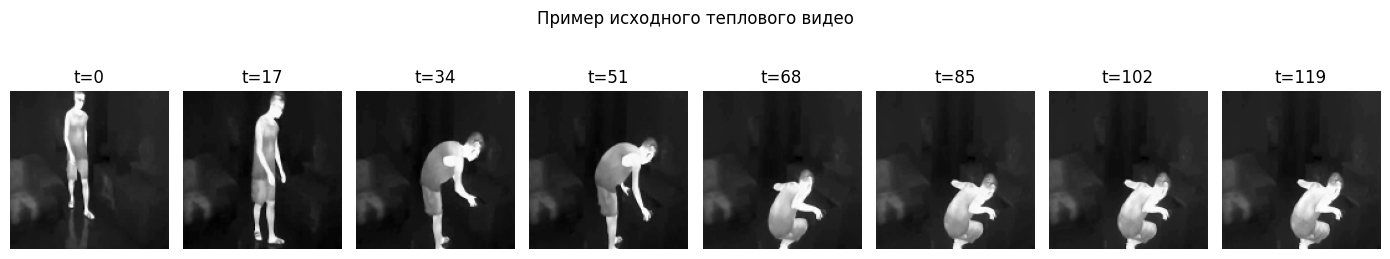

In [55]:
sample_path = DATA_ROOT / train_dataset.df.iloc[0]["filepath"]
frames = load_grayscale_video(sample_path)
show_video_frames(frames, title="Пример исходного теплового видео")

## Визуализация событийных каналов

Для каждого видео формируется 7-канальное представление.  
Ниже показан пример одного временного окна после преобразования исходных кадров в событийные признаки.

Форма одного видео после обработки: torch.Size([10, 40, 7, 128, 128])
Класс: object_interaction


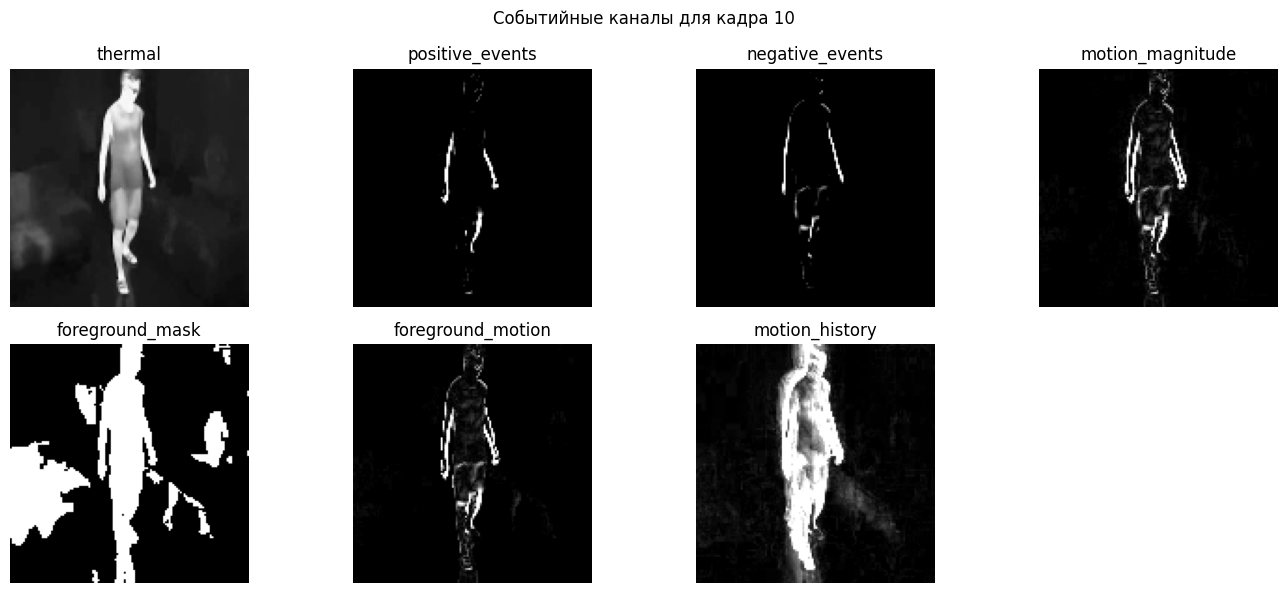

In [56]:
idx_to_class = {v: k for k, v in class_to_idx.items()}

windows, label = train_dataset[0]

print("Форма одного видео после обработки:", windows.shape)
print("Класс:", idx_to_class[int(label)])

event_tensor = windows[0].numpy()

show_event_channels(event_tensor, frame_idx=10)

In [57]:
NUM_WORKERS = 2
BATCH_SIZE = 8
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
)

In [58]:
class SpikeFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        return (input > 0).float()

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors

        # surrogate gradient
        grad = grad_output.clone()
        sg = 1.0 / (1.0 + input.abs()) ** 2

        return grad * sg


spike_fn = SpikeFn.apply


class LIFLayer(nn.Module):
    def __init__(self, beta=0.9):
        super().__init__()
        self.beta = beta

    def forward(self, input_seq):
        """
        input_seq: [B, T, D]
        """
        B, T, D = input_seq.shape

        mem = torch.zeros(
            B,
            D,
            device=input_seq.device,
            dtype=input_seq.dtype
        )

        spikes = []

        for t in range(T):
            mem = self.beta * mem + input_seq[:, t]
            spk = spike_fn(mem - 1.0)
            mem = mem * (1.0 - spk)

            spikes.append(spk)

        spikes = torch.stack(spikes, dim=1)

        return spikes


class ThermalPLSMAction(nn.Module):
    def __init__(
        self,
        num_classes=3,
        beta=0.9,
        embedding_dim=128,
        reservoir_size=256,
        reservoir_gain=3.0,
        motion_dim=32,
        input_channels=7,
    ):
        super().__init__()

        self.num_classes = num_classes
        self.embedding_dim = embedding_dim
        self.reservoir_size = reservoir_size
        self.motion_dim = motion_dim
        self.reservoir_gain = reservoir_gain

        self.conv = nn.Sequential(
            nn.Conv2d(input_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.frame_embed = nn.Sequential(
            nn.Linear(64, embedding_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        self.reservoir_in = nn.Linear(
            embedding_dim,
            reservoir_size
        )

        self.lif = LIFLayer(beta=beta)

        self.motion_encoder = nn.Sequential(
            nn.Conv2d(2, 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.motion_fc = nn.Sequential(
            nn.Linear(16, motion_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        temporal_dim = reservoir_size + motion_dim
        self.temporal_dim = temporal_dim

        self.temporal_conv = nn.Sequential(
            nn.Conv1d(
                temporal_dim,
                temporal_dim,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Conv1d(
                temporal_dim,
                temporal_dim,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),
        )

        self.temporal_attn = nn.Sequential(
            nn.Linear(temporal_dim, temporal_dim // 2),
            nn.ReLU(),
            nn.Linear(temporal_dim // 2, 1),
        )

        self.readout_dim = temporal_dim * 3

        self.classifier = nn.Sequential(
            nn.LayerNorm(self.readout_dim),
            nn.Dropout(0.3),
            nn.Linear(self.readout_dim, num_classes),
        )

    def forward(self, x):

        B, T, C, H, W = x.shape

        x_flat = x.reshape(B * T, C, H, W)

        cnn_feat = self.conv(x_flat)
        cnn_feat = cnn_feat.flatten(1)  # [B*T, 64]

        frame_emb = self.frame_embed(cnn_feat)
        frame_emb = frame_emb.reshape(B, T, -1)

        reservoir_input = self.reservoir_in(frame_emb)
        reservoir_input = reservoir_input * self.reservoir_gain

        reservoir_spikes = self.lif(reservoir_input)  # [B, T, reservoir_size]

        motion_input = x[:, :, [5, 6], :, :]       # foreground_motion + motion_history
        motion_input_flat = motion_input.reshape(B * T, 2, H, W)

        motion_feat = self.motion_encoder(motion_input_flat)
        motion_feat = motion_feat.flatten(1)
        motion_feat = self.motion_fc(motion_feat)
        motion_feat = motion_feat.reshape(B, T, -1)

        frame_features = torch.cat(
            [
                reservoir_spikes,
                motion_feat,
            ],
            dim=2
        )  # [B, T, temporal_dim]

        temporal_x = frame_features.transpose(1, 2)  # [B, D, T]
        temporal_x = self.temporal_conv(temporal_x)
        temporal_x = temporal_x.transpose(1, 2)      # [B, T, D]

        attn_scores = self.temporal_attn(temporal_x).squeeze(-1)
        attn_weights = torch.softmax(attn_scores, dim=1)

        attn_feat = (
            temporal_x * attn_weights.unsqueeze(-1)
        ).sum(dim=1)

        mean_feat = temporal_x.mean(dim=1)
        max_feat = temporal_x.max(dim=1).values

        readout_feat = torch.cat(
            [
                attn_feat,
                mean_feat,
                max_feat,
            ],
            dim=1
        )

        logits = self.classifier(readout_feat)

        return logits, readout_feat

In [59]:
class FeatureAttentionPool(nn.Module):
    def __init__(self, feature_dim, num_classes, top_k=3):
        super().__init__()

        self.top_k = top_k

        self.attn = nn.Sequential(
            nn.Linear(feature_dim, feature_dim // 4),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(feature_dim // 4, 1),
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(feature_dim),
            nn.Dropout(0.3),
            nn.Linear(feature_dim, num_classes),
        )

        self.window_object_head = nn.Sequential(
            nn.LayerNorm(feature_dim),
            nn.Linear(feature_dim, feature_dim // 4),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(feature_dim // 4, 1),
        )

    def forward(self, features):
        """
        features: [B, N, feature_dim]
        """

        B, N, D = features.shape

        # Основная агрегация окон
        attn_scores = self.attn(features).squeeze(-1)
        attn_weights = torch.softmax(attn_scores, dim=1)

        video_feature = (
            features * attn_weights.unsqueeze(-1)
        ).sum(dim=1)

        logits_video = self.classifier(video_feature)

        # Оконный object-evidence
        window_object_logits = self.window_object_head(features).squeeze(-1)

        k = min(self.top_k, N)

        topk_object_logits = torch.topk(
            window_object_logits,
            k=k,
            dim=1
        ).values

        video_object_logit = topk_object_logits.mean(dim=1)

        return logits_video, window_object_logits, video_object_logit, attn_weights

In [60]:
def model_selection_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    passive_rec = cm[0, 0] / max(1, cm[0].sum())
    object_rec = cm[1, 1] / max(1, cm[1].sum())
    physical_rec = cm[2, 2] / max(1, cm[2].sum())

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    min_recall = min(passive_rec, object_rec, physical_rec)
    po_balance = min(passive_rec, object_rec)

    penalty = 0.0
    penalty += max(0.0, 0.88 - passive_rec) * 1.0
    penalty += max(0.0, 0.88 - object_rec) * 1.0
    penalty += max(0.0, 0.88 - physical_rec) * 0.8

    score = (
        0.30 * acc
        + 0.30 * macro_f1
        + 0.20 * po_balance
        + 0.20 * min_recall
        - penalty
    )

    return score, passive_rec, object_rec, physical_rec

In [61]:
def passive_object_margin_loss(logits, targets, margin=0.35):
    passive_logit = logits[:, 0]
    object_logit = logits[:, 1]

    losses = []

    passive_mask = targets == 0
    object_mask = targets == 1

    if passive_mask.any():
        loss_passive = torch.relu(
            margin - (
                passive_logit[passive_mask]
                - object_logit[passive_mask]
            )
        )
        losses.append(loss_passive.mean())

    if object_mask.any():
        loss_object = torch.relu(
            margin - (
                object_logit[object_mask]
                - passive_logit[object_mask]
            )
        )
        losses.append(loss_object.mean())

    if len(losses) == 0:
        return torch.tensor(0.0, device=logits.device)

    return torch.stack(losses).mean()

In [62]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none', weight=self.weight)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

In [63]:
def train_one_epoch(
    model,
    aggregator,
    loader,
    optimizer,
    criterion,
    device,
):
    model.train()
    aggregator.train()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    for videos, targets in tqdm(loader, desc="Train", leave=False):
        videos = videos.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        B, N, T, C, H, W = videos.shape

        videos = videos.reshape(B * N, T, C, H, W)

        optimizer.zero_grad(set_to_none=True)

        logits_window, features_window = model(videos)

        features_window = features_window.reshape(B, N, -1)

        logits_video, window_object_logits, video_object_logit, attn_weights = aggregator(
            features_window
        )

        loss_main = criterion(logits_video, targets)

        loss_po = passive_object_margin_loss(
            logits_video,
            targets,
            margin=0.35,
        )

        loss = loss_main + 0.03 * loss_po

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            list(model.parameters()) + list(aggregator.parameters()),
            max_norm=1.0
        )

        optimizer.step()

        preds = logits_video.argmax(dim=1)

        total_loss += loss.item() * B

        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)

    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average="macro")

    return avg_loss, acc, f1

In [64]:
@torch.no_grad()
def evaluate(
    model,
    aggregator,
    loader,
    criterion,
    device,
):
    model.eval()
    aggregator.eval()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    for videos, targets in tqdm(loader, desc="Eval", leave=False):
        videos = videos.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        B, N, T, C, H, W = videos.shape
        videos = videos.reshape(B * N, T, C, H, W)

        logits_window, features_window = model(videos)

        features_window = features_window.reshape(B, N, -1)

        logits_video, window_object_logits, video_object_logit, attn_weights = aggregator(
            features_window
        )

        loss_main = criterion(logits_video, targets)

        loss_po = passive_object_margin_loss(
            logits_video,
            targets,
            margin=0.35,
        )

        loss = loss_main + 0.03 * loss_po

        preds = logits_video.argmax(dim=1)

        total_loss += loss.item() * B

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

    loss_mean = total_loss / len(loader.dataset)

    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average="macro")

    return loss_mean, acc, f1, np.array(all_targets), np.array(all_preds)

# Создание модели

In [65]:
NUM_CLASSES = 3

embedding_dim = 128
reservoir_size = 256
motion_dim = 32
reservoir_gain = 3.0

model = ThermalPLSMAction(
    num_classes=NUM_CLASSES,
    beta=0.9,
    embedding_dim=embedding_dim,
    reservoir_size=reservoir_size,
    reservoir_gain=reservoir_gain,
    motion_dim=motion_dim,
    input_channels=7,
).to(device)

feature_dim = model.readout_dim

aggregator = FeatureAttentionPool(
    feature_dim=feature_dim,
    num_classes=NUM_CLASSES,
).to(device)

print("feature_dim:", feature_dim)
class_weights = torch.tensor(
    [1.00, 1.25, 1.10],
    dtype=torch.float32
).to(device)

criterion = FocalLoss(alpha=0.25, gamma=2.0, weight=class_weights)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(aggregator.parameters()),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)


feature_dim: 864


## Архитектура модели

Модель принимает на вход последовательность тепловых кадров, преобразованную в 7-канальное событийное представление.

Основные этапы обработки:

1. извлечение пространственных признаков с помощью CNN;
2. обработка временной динамики через LIF-слой;
3. выделение признаков движения в отдельной ветви;
4. объединение пространственных и motion-признаков;
5. temporal convolution для анализа последовательности;
6. attention pooling для выделения наиболее информативных моментов;
7. финальная классификация действия.

In [66]:
num_epochs = 35
patience = 7

best_score = -1e9
best_state = None
patience_counter = 0

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "selection_score": [],
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        aggregator,
        train_loader,
        optimizer,
        criterion,
        device,
    )

    val_loss, val_acc, val_f1, y_true_val, y_pred_val = evaluate(
        model=model,
        aggregator=aggregator,
        loader=val_loader,
        criterion=criterion,
        device=device,
    )

    score, passive_rec, object_rec, physical_rec = model_selection_score(
        y_true_val,
        y_pred_val,
    )

    scheduler.step(score)

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["selection_score"].append(score)

    print(
        f"Epoch {epoch:02d}/{num_epochs} | "
        f"train_loss={train_loss:.4f} "
        f"train_acc={train_acc:.4f} "
        f"train_f1={train_f1:.4f} | "
        f"val_loss={val_loss:.4f} "
        f"val_acc={val_acc:.4f} "
        f"val_f1={val_f1:.4f} | "
        f"score={score:.4f} "
        f"passive_rec={passive_rec:.4f} "
        f"object_rec={object_rec:.4f} "
        f"physical_rec={physical_rec:.4f}"
    )

    if score > best_score:
        best_score = score
        patience_counter = 0

        best_state = {
            "model": {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            },
            "aggregator": {
                k: v.detach().cpu().clone()
                for k, v in aggregator.state_dict().items()
            },
            "epoch": epoch,
            "score": score,
            "val_f1": val_f1,
            "val_acc": val_acc,
            "passive_rec": passive_rec,
            "object_rec": object_rec,
            "physical_rec": physical_rec,
        }

        print("  New best model")

    else:
        patience_counter += 1

        print(
            f"  No improvement. "
            f"Patience {patience_counter}/{patience}"
        )

    if patience_counter >= patience:
        print("Early stopping")
        break

Train:   0%|          | 0/57 [00:00<?, ?it/s]

Eval:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch 01/35 | train_loss=0.0883 train_acc=0.7445 train_f1=0.5802 | val_loss=0.0384 val_acc=0.8807 val_f1=0.6195 | score=-0.0581 passive_rec=0.9800 object_rec=0.9792 physical_rec=0.0000
  New best model


Train:   0%|          | 0/57 [00:00<?, ?it/s]

Eval:   0%|          | 0/14 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch 34/35 | train_loss=0.0091 train_acc=0.9780 train_f1=0.9737 | val_loss=0.0283 val_acc=0.9541 val_f1=0.9131 | score=0.7793 passive_rec=0.9800 object_rec=0.9792 physical_rec=0.7273
  No improvement. Patience 5/7


Train:   0%|          | 0/57 [00:00<?, ?it/s]

Eval:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch 35/35 | train_loss=0.0087 train_acc=0.9802 train_f1=0.9717 | val_loss=0.0251 val_acc=0.9633 val_f1=0.9307 | score=0.7875 passive_rec=0.9800 object_rec=1.0000 physical_rec=0.7273
  No improvement. Patience 6/7


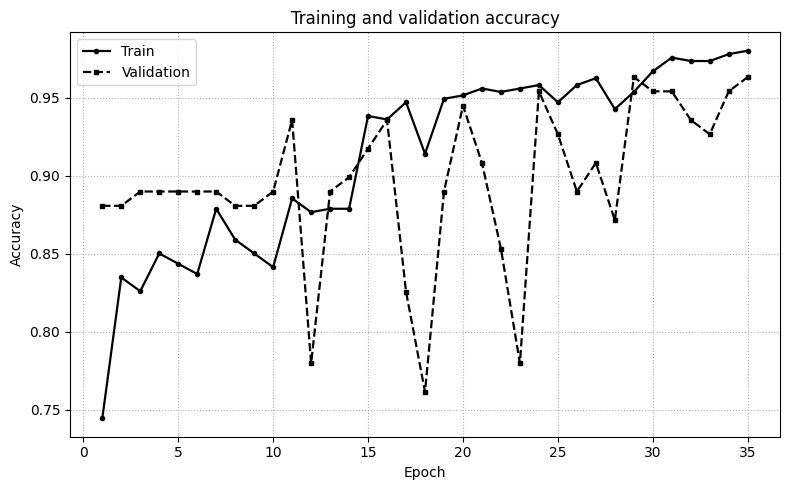

Saved: /content/drive/MyDrive/training_plots_bw1/accuracy_bw.png


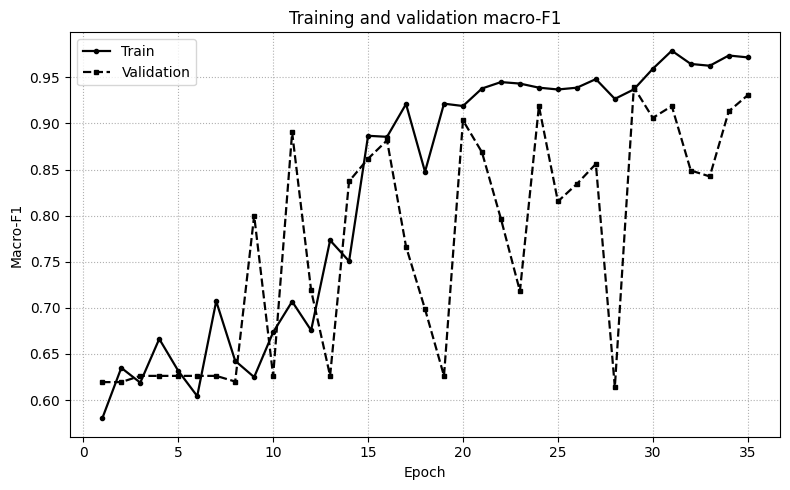

Saved: /content/drive/MyDrive/training_plots_bw1/macro_f1_bw.png


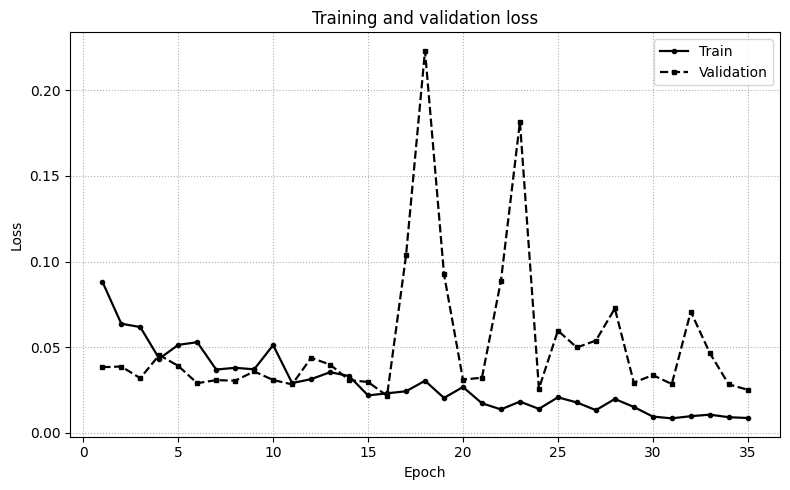

Saved: /content/drive/MyDrive/training_plots_bw1/loss_bw.png


In [67]:
hist_df = pd.DataFrame(history)

if "epoch" not in hist_df.columns:
    hist_df["epoch"] = range(1, len(hist_df) + 1)

required_cols = [
    "train_loss", "val_loss",
    "train_acc", "val_acc",
    "train_f1", "val_f1"
]

missing = [c for c in required_cols if c not in hist_df.columns]
if missing:
    raise ValueError(f"В history нет колонок: {missing}")

SAVE_DIR = Path("/content/drive/MyDrive/training_plots_bw1")
SAVE_DIR.mkdir(exist_ok=True)


def plot_metric_bw(
    df,
    y_train,
    y_val,
    title,
    ylabel,
    save_name,
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        df["epoch"],
        df[y_train],
        linestyle="-",
        marker="o",
        markersize=3,
        linewidth=1.6,
        label="Train",
        color="black",
    )

    plt.plot(
        df["epoch"],
        df[y_val],
        linestyle="--",
        marker="s",
        markersize=3,
        linewidth=1.6,
        label="Validation",
        color="black",
    )

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.grid(True, linestyle=":", linewidth=0.8)
    plt.legend()
    plt.tight_layout()

    save_path = SAVE_DIR / save_name
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {save_path}")


plot_metric_bw(
    hist_df,
    y_train="train_acc",
    y_val="val_acc",
    title="Training and validation accuracy",
    ylabel="Accuracy",
    save_name="accuracy_bw.png",
)

plot_metric_bw(
    hist_df,
    y_train="train_f1",
    y_val="val_f1",
    title="Training and validation macro-F1",
    ylabel="Macro-F1",
    save_name="macro_f1_bw.png",
)

plot_metric_bw(
    hist_df,
    y_train="train_loss",
    y_val="val_loss",
    title="Training and validation loss",
    ylabel="Loss",
    save_name="loss_bw.png",
)

In [68]:
model.load_state_dict(best_state["model"])
aggregator.load_state_dict(best_state["aggregator"])

model.to(device)
aggregator.to(device)

print(
    f"Loaded best model from epoch {best_state['epoch']} | "
    f"score={best_state['score']:.4f} | "
    f"val_f1={best_state['val_f1']:.4f} | "
    f"val_acc={best_state['val_acc']:.4f} | "
    f"passive_rec={passive_rec:.4f} "
    f"object_rec={object_rec:.4f} "
    f"physical_rec={physical_rec:.4f}"
)


Loaded best model from epoch 29 | score=0.9443 | val_f1=0.9393 | val_acc=0.9633 | passive_rec=0.9800 object_rec=1.0000 physical_rec=0.7273


Eval:   0%|          | 0/17 [00:00<?, ?it/s]

TEST loss=0.0105
TEST acc =0.9769
TEST f1  =0.9834
                    precision    recall  f1-score   support

     passive_state     1.0000    0.9492    0.9739        59
object_interaction     0.9538    1.0000    0.9764        62
 physical_activity     1.0000    1.0000    1.0000         9

          accuracy                         0.9769       130
         macro avg     0.9846    0.9831    0.9834       130
      weighted avg     0.9780    0.9769    0.9769       130



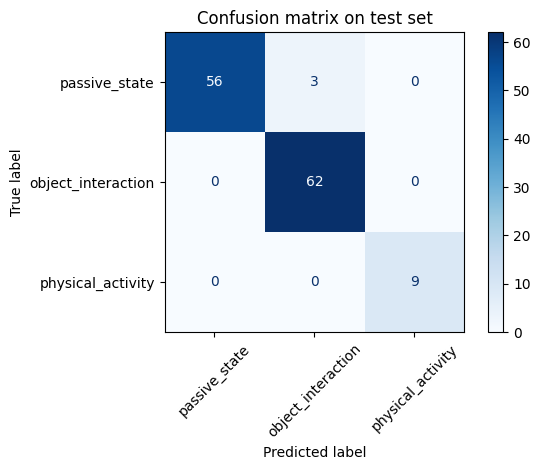

In [69]:
test_loss, test_acc, test_f1, y_true, y_pred = evaluate(
    model,
    aggregator,
    test_loader,
    criterion,
    device,
)

print(f"TEST loss={test_loss:.4f}")
print(f"TEST acc ={test_acc:.4f}")
print(f"TEST f1  ={test_f1:.4f}")

print(classification_report(
    y_true,
    y_pred,
    target_names=[idx_to_class[i] for i in range(3)],
    digits=4
))

labels = list(class_to_idx.keys())

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=labels,
    cmap="Blues",
    xticks_rotation=45,
)

plt.title("Confusion matrix on test set")
plt.tight_layout()
plt.show()

# Анализ ошибок

In [70]:
test_pred_df = test_dataset.df.copy()

test_pred_df["true"] = y_true
test_pred_df["pred"] = y_pred

test_pred_df["true_class"] = test_pred_df["true"].map(idx_to_class)
test_pred_df["pred_class"] = test_pred_df["pred"].map(idx_to_class)
test_pred_df["correct"] = test_pred_df["true"] == test_pred_df["pred"]

errors = test_pred_df[test_pred_df["correct"] == False].copy()

print(errors["full_label"].value_counts())
print(pd.crosstab(errors["full_label"], errors["pred_class"]))


full_label
sit desk     2
sit chair    1
Name: count, dtype: int64
pred_class  object_interaction
full_label                    
sit chair                    1
sit desk                     2


In [71]:
display(errors[
    [
        "filepath",
        "full_label",
        "true_class",
        "pred_class",
        "duration",
        "original_duration",
        "motion_score",
        "quality_flags",
        "source_date",
    ]
])

,filepath,full_label,true_class,pred_class,duration,original_duration,motion_score,quality_flags,source_date
42,test/sit_chair/20221015_7__20221015_7_split1__...,sit chair,passive_state,object_interaction,16.0,26.464000,0.012691,ok,20221015
77,test/sit_desk/20221027_1__20221027_1_split1__p...,sit desk,passive_state,object_interaction,16.0,15.433333,0.020912,high_motion_passive,20221027
97,test/sit_desk/20221027_1__20221027_1_split1__p...,sit desk,passive_state,object_interaction,16.0,1.436000,0.039312,high_motion_passive,20221027


# Сохранение модели

In [72]:
SAVE_PATH = Path("/content/drive/MyDrive/model_dataset_v7.pth")

checkpoint = {
    "model_state_dict": model.state_dict(),
    "aggregator_state_dict": aggregator.state_dict(),

    "best_state": best_state,

    "class_to_id": {
        "passive_state": 0,
        "object_interaction": 1,
        "physical_activity": 2,
    },

    "id_to_class": {
        0: "passive_state",
        1: "object_interaction",
        2: "physical_activity",
    },

    "config": {
        "window_size": 40,
        "n_windows": 10,
        "resize": (128, 128),
        "mode": "action_aware",
        "main_task": "three_label",
        "num_classes": 3,
        "dataset": "dataset_v7",
    },
}

torch.save(checkpoint, SAVE_PATH)

print(f"Saved to {SAVE_PATH}")

Saved to /content/drive/MyDrive/model_dataset_v7.pth
